# Binary footware classifcation

In [1]:
import torchvision
import torch
import torch.nn as nn 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from torchinfo import summary

In [2]:
rawTrain = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True)
rawTest = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True)

XTrain = rawTrain.data
XTest = rawTest.data

yTrain = rawTrain.targets
yTest = rawTest.targets

XTrain, XTest, yTrain, yTest

(tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         ...,
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0

In [3]:
yTrain = ((yTrain == 5) | (yTrain == 7) | (yTrain == 9)).double()
yTest = ((yTest == 5) | (yTest == 7) | (yTest == 9)).double()
yTrain, yTest

(tensor([1., 0., 0.,  ..., 0., 0., 1.], dtype=torch.float64),
 tensor([1., 0., 0.,  ..., 0., 0., 1.], dtype=torch.float64))

In [4]:

yTrain = yTrain.reshape(-1, 1)
yTest = yTest.reshape(-1, 1)
yTrain, yTest

(tensor([[1.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [1.]], dtype=torch.float64),
 tensor([[1.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [1.]], dtype=torch.float64))

In [5]:
torch.set_default_dtype(torch.float64)
XTrain = torch.tensor(XTrain / 255)
XTest = torch.tensor(XTest / 255)
XTrain, XTest

/tmp/ipykernel_25461/3466273115.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XTrain = torch.tensor(XTrain / 255)
/tmp/ipykernel_25461/3466273115.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XTest = torch.tensor(XTest / 255)


(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         ...,
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 

In [6]:
def displayImage(img):
    plt.imshow(img, cmap="binary")
    plt.axis("off")


In [7]:
x = ((0.90 + 0.2) * torch.rand(XTrain.shape, dtype=torch.float64))
x

tensor([[[1.0713, 0.4380, 0.0739,  ..., 0.1014, 0.6073, 0.0553],
         [0.4832, 0.3061, 0.4950,  ..., 0.8136, 0.8937, 0.2631],
         [0.2794, 0.8564, 0.1236,  ..., 0.8199, 0.2593, 0.0794],
         ...,
         [0.0079, 0.5658, 0.9470,  ..., 0.6843, 0.5849, 0.0804],
         [0.2923, 0.5548, 0.9059,  ..., 0.2479, 0.6359, 0.8330],
         [0.4876, 0.9015, 0.6847,  ..., 0.0873, 0.6632, 0.5049]],

        [[0.1688, 0.1959, 0.0773,  ..., 0.7833, 0.0191, 0.0502],
         [0.4193, 0.2736, 0.1017,  ..., 0.9063, 0.9487, 0.8199],
         [1.0647, 0.9450, 0.8282,  ..., 0.2746, 0.6841, 0.4761],
         ...,
         [0.7744, 0.8285, 1.0720,  ..., 0.4195, 1.0112, 0.6299],
         [0.7232, 0.1518, 1.0345,  ..., 1.0020, 1.0490, 0.8872],
         [0.5680, 1.0052, 0.3624,  ..., 0.4219, 0.1164, 0.2357]],

        [[0.4027, 0.7467, 0.0300,  ..., 0.9415, 0.9339, 0.1915],
         [0.6998, 0.6227, 0.5128,  ..., 1.0650, 0.3665, 0.1439],
         [0.1647, 0.6381, 0.6339,  ..., 0.2071, 0.4169, 0.

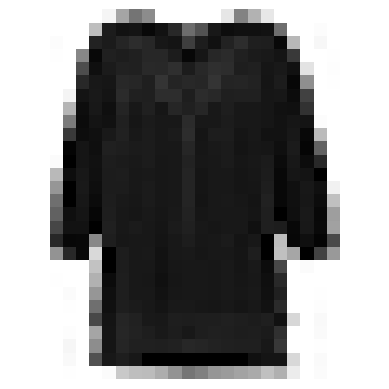

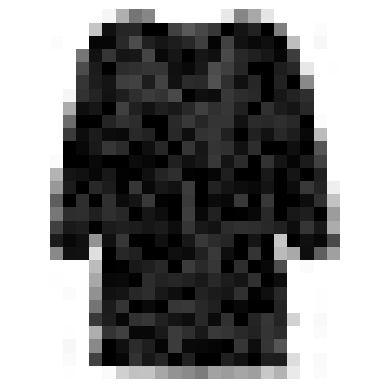

In [8]:
randomIndex = np.random.randint(0, 60000)
displayImage(XTrain[randomIndex])
plt.show()
XTrainRandomPattern = torch.clamp((XTrain.detach().clone() * (0.85 + 0.3 * torch.rand(XTrain.shape, dtype=torch.float64))), min=0, max=1)
displayImage(XTrainRandomPattern[randomIndex])
plt.show()

In [9]:
XTrainExtended = torch.concat((XTrain, XTrainRandomPattern), axis= 0)
XTrainExtended.shape

torch.Size([120000, 28, 28])

In [10]:
yTrainExtended = torch.concat((yTrain, yTrain), axis= 0)
yTrainExtended.shape

torch.Size([120000, 1])

# Model making and training

In [11]:
torch.manual_seed(67)
class FootwareClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.neuralNetwork = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, X):
        return self.neuralNetwork(X)

In [12]:
model = FootwareClassifier().double()
summary(model, input_size= (32, 28, 28), 
    dtypes=[torch.float64])

Layer (type:depth-idx)                   Output Shape              Param #
FootwareClassifier                       [32, 1]                   --
├─Sequential: 1-1                        [32, 1]                   --
│    └─Flatten: 2-1                      [32, 784]                 --
│    └─Linear: 2-2                       [32, 128]                 100,480
│    └─ReLU: 2-3                         [32, 128]                 --
│    └─Linear: 2-4                       [32, 128]                 16,512
│    └─ReLU: 2-5                         [32, 128]                 --
│    └─Linear: 2-6                       [32, 128]                 16,512
│    └─ReLU: 2-7                         [32, 128]                 --
│    └─Linear: 2-8                       [32, 1]                   129
│    └─Sigmoid: 2-9                      [32, 1]                   --
Total params: 133,633
Trainable params: 133,633
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 4.28
Input size (MB): 0.20
Forward

In [13]:
torch.set_num_threads(10)
epochs = 60
alpha = 0.0001

lossFunction = nn.BCELoss()

optimizer = torch.optim.SGD(model.parameters(), lr=alpha)

trainLossH = []
evalLossH = []

trainAccuracyH = []
evalAccuracyH = []

for epoch in range(epochs):

    yHat = model(XTrainExtended)

    loss = lossFunction(yHat, yTrainExtended)
    optimizer.zero_grad()

    loss.backward()
    optimizer.step()

    if((epoch + 1) %5 == 0):

        with torch.no_grad():

            trainLossH.append(loss.item())

            yEval = model(XTest)
            evalLoss = lossFunction(yEval, yTest)
            evalLossH.append(evalLoss.item())

            yHat = (yHat > 0.5).int()
            accuracy = (yHat == yTrainExtended).float().mean()
            trainAccuracyH.append(accuracy.item())

            yEval = (yEval > 0.5).int()
            evalAccuracy = (yEval == yTest).float().mean()
            evalAccuracyH.append(evalAccuracy.item())

            print(
                f"Epoch: {epoch + 1}, "
                f"train loss: {loss.item()}, "
                f"train accuracy: {accuracy.item() * 100:.2f}% | "
                f"evaluation loss: {evalLoss.item()}, "
                f"evaluation accuracy: {evalAccuracy.item() * 100:.2f}%"
            )

Epoch: 5, train loss: 0.6895752439809503, train accuracy: 78.74% | evaluation loss: 0.6895557286714041, evaluation accuracy: 78.84%
Epoch: 10, train loss: 0.6895171619849637, train accuracy: 78.90% | evaluation loss: 0.6894975796164717, evaluation accuracy: 78.99%
Epoch: 15, train loss: 0.6894591006737127, train accuracy: 79.04% | evaluation loss: 0.6894394510088302, evaluation accuracy: 79.09%
Epoch: 20, train loss: 0.6894010608589598, train accuracy: 79.17% | evaluation loss: 0.6893813445523873, evaluation accuracy: 79.23%
Epoch: 25, train loss: 0.6893430428429423, train accuracy: 79.31% | evaluation loss: 0.6893232594075032, evaluation accuracy: 79.31%
Epoch: 30, train loss: 0.6892850466313701, train accuracy: 79.42% | evaluation loss: 0.6892651963838246, evaluation accuracy: 79.44%
Epoch: 35, train loss: 0.6892270714577547, train accuracy: 79.53% | evaluation loss: 0.6892071537632372, evaluation accuracy: 79.54%
Epoch: 40, train loss: 0.6891691168891969, train accuracy: 79.61% | ev

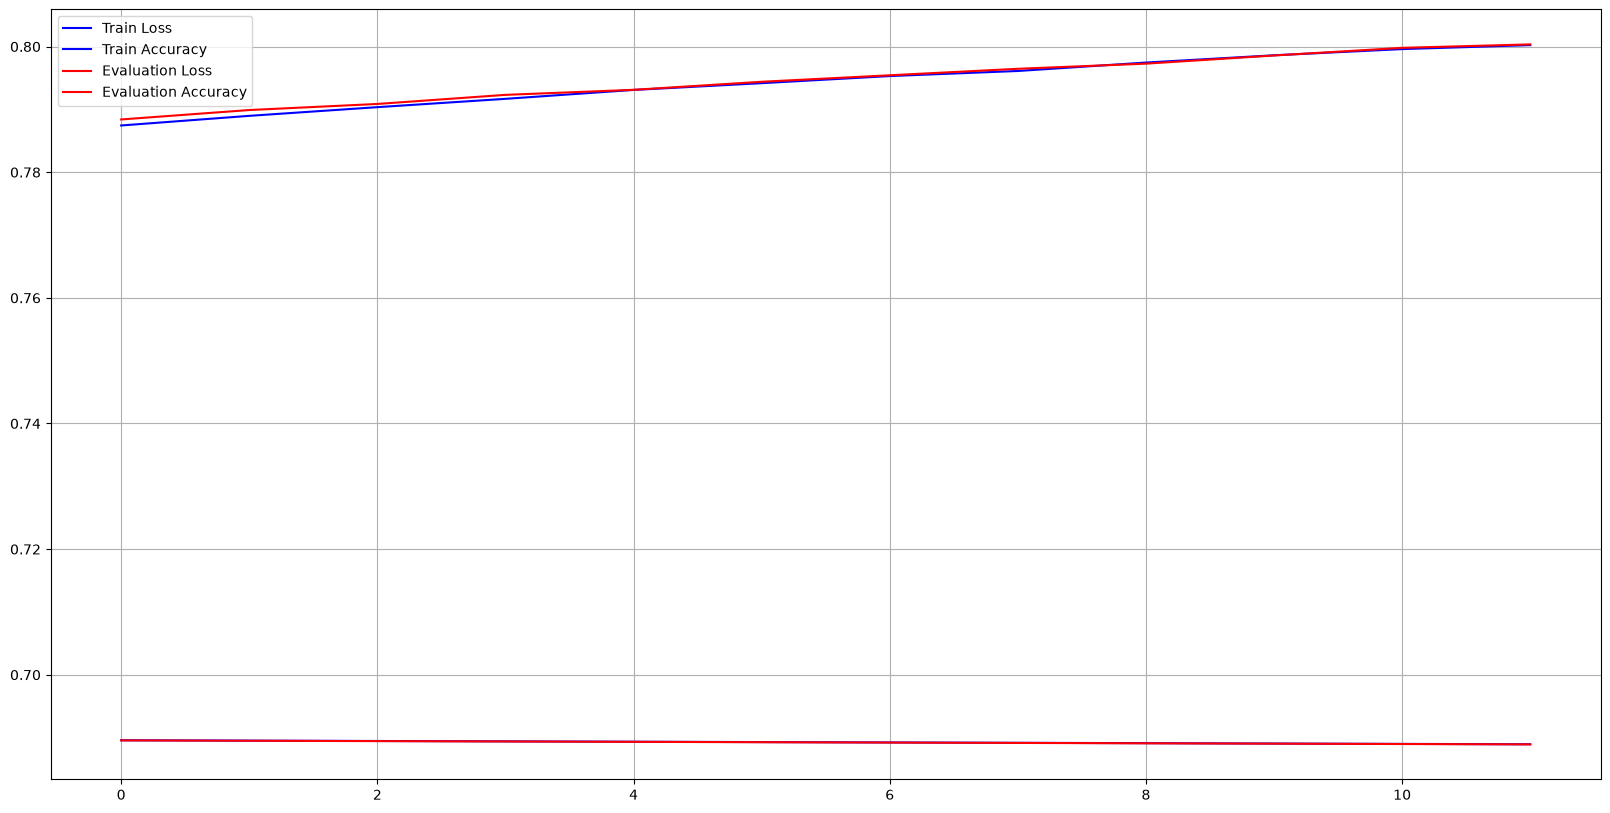

In [26]:
plt.figure(figsize=(20, 10))
plt.grid(True)
plt.plot(trainLossH, c="b", label = "Train Loss")
plt.plot(trainAccuracyH, c = "b", label = "Train Accuracy")
plt.plot(evalLossH, c = "r", label = "Evaluation Loss")
plt.plot(evalAccuracyH, c = "r", label = "Evaluation Accuracy")
plt.legend(loc="best")
plt.show()